# Spatial Cross-Validated XGBoost – Multi-Threshold Accessibility Index

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import shap

import seaborn as sns
sns.set_theme()

In [2]:
# CONFIG
STATE = "08"
COUNTIES = ["031"]
RANDOM_STATE = 42
N_CLUSTERS = 5

# LOAD DATA
X_df = pd.read_parquet(
    "../data/processed_predictors/denver_2024_predictor_dataset.parquet"
)

y_df = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-CO_counties-031_year-2023_thresholds-15-30-45-60.parquet"
)

print(X_df.shape, y_df.shape)

(178, 44) (178, 5)


In [3]:
# # CONFIG
# STATE = "13"
# COUNTIES = ["121", "089", "067", "135"]
# RANDOM_STATE = 42
# N_CLUSTERS = 5

# # LOAD DATA
# X_df = pd.read_parquet(
#     "../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
# )

# y_df = pd.read_parquet(
#     "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
# )

# print(X_df.shape, y_df.shape)

## Preprocessing

In [4]:
# INCREMENTAL ACCESSIBILITY BANDS
y_df["band_0_15"] = y_df["jobs_15min"]

y_df["band_15_30"] = (
    y_df["jobs_30min"]
    - y_df["jobs_15min"]
)

y_df["band_30_45"] = (
    y_df["jobs_45min"]
    - y_df["jobs_30min"]
)

y_df["band_45_60"] = (
    y_df["jobs_60min"]
    - y_df["jobs_45min"]
)

# WEIGHTED ACCESSIBILITY INDEX
weighted_sum = (
      1.0 * y_df["band_0_15"]
    + 0.7 * y_df["band_15_30"]
    + 0.4 * y_df["band_30_45"]
    + 0.2 * y_df["band_45_60"]
)

y_df["access_index"] = np.log1p(weighted_sum) # Weighted Incremental Accessibility Index
# y_df["access_index"] = weighted_sum

low = y_df["access_index"].quantile(0.05)
high = y_df["access_index"].quantile(0.95)

y_df["access_index"] = (
    (y_df["access_index"] - low) / (high - low)
)

# clip to [0, 1]
y_df["access_index"] = y_df["access_index"].clip(0, 1)

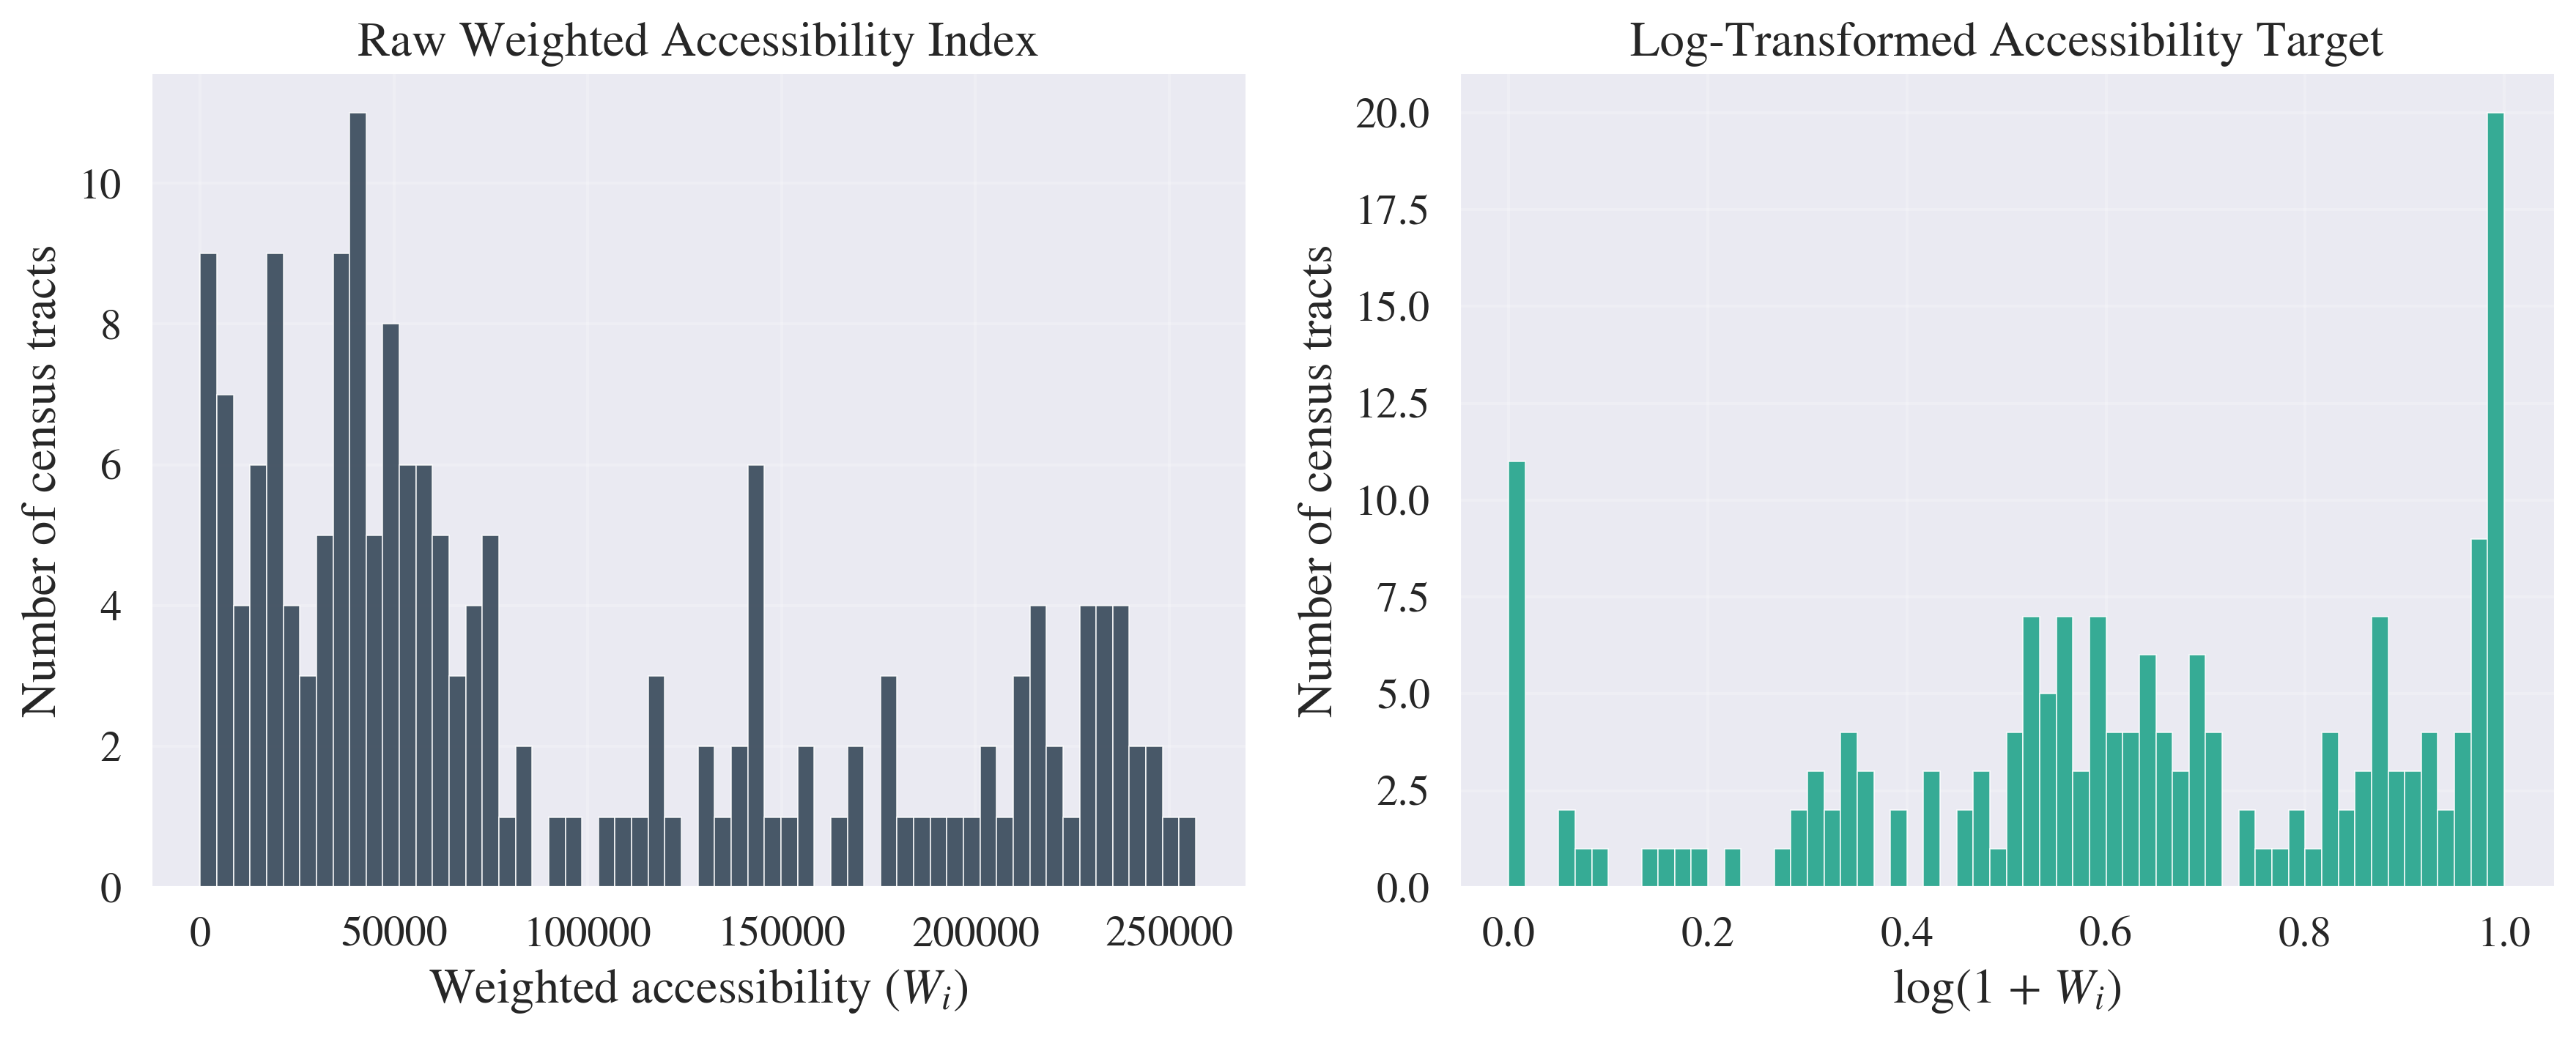

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",

    # ---- main text size ----
    "font.size": 16,

    # ---- axis titles ----
    "axes.titlesize": 16,
    "axes.labelsize": 16,

    # ---- tick labels (numbers) ----
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

common_hist_style = dict(
    bins=60,
    edgecolor="white",
    linewidth=0.4,
    alpha=0.85
)

# Raw weighted accessibility
axes[0].hist(
    weighted_sum,
    color="#2C3E50",
    **common_hist_style
)
axes[0].set_title("Raw Weighted Accessibility Index")
axes[0].set_xlabel(r"Weighted accessibility ($W_i$)")
axes[0].set_ylabel("Number of census tracts")

# Log-transformed target
axes[1].hist(
    y_df["access_index"],
    color="#16A085",
    **common_hist_style
)
axes[1].set_title("Log-Transformed Accessibility Target")
axes[1].set_xlabel(r"log(1 + $W_i$)")
axes[1].set_ylabel("Number of census tracts")

plt.tight_layout()
plt.show()

In [6]:
# Merge data
df = X_df.merge(
    y_df[["from_id"] + ["access_index"]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

In [7]:
# Load and merge geometry
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)
tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()
tracts["tract_id"] = tracts["GEOID"].astype(str)

df = df.merge(
    tracts[["tract_id", "geometry"]],
    on="tract_id",
    how="left"
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts.crs)

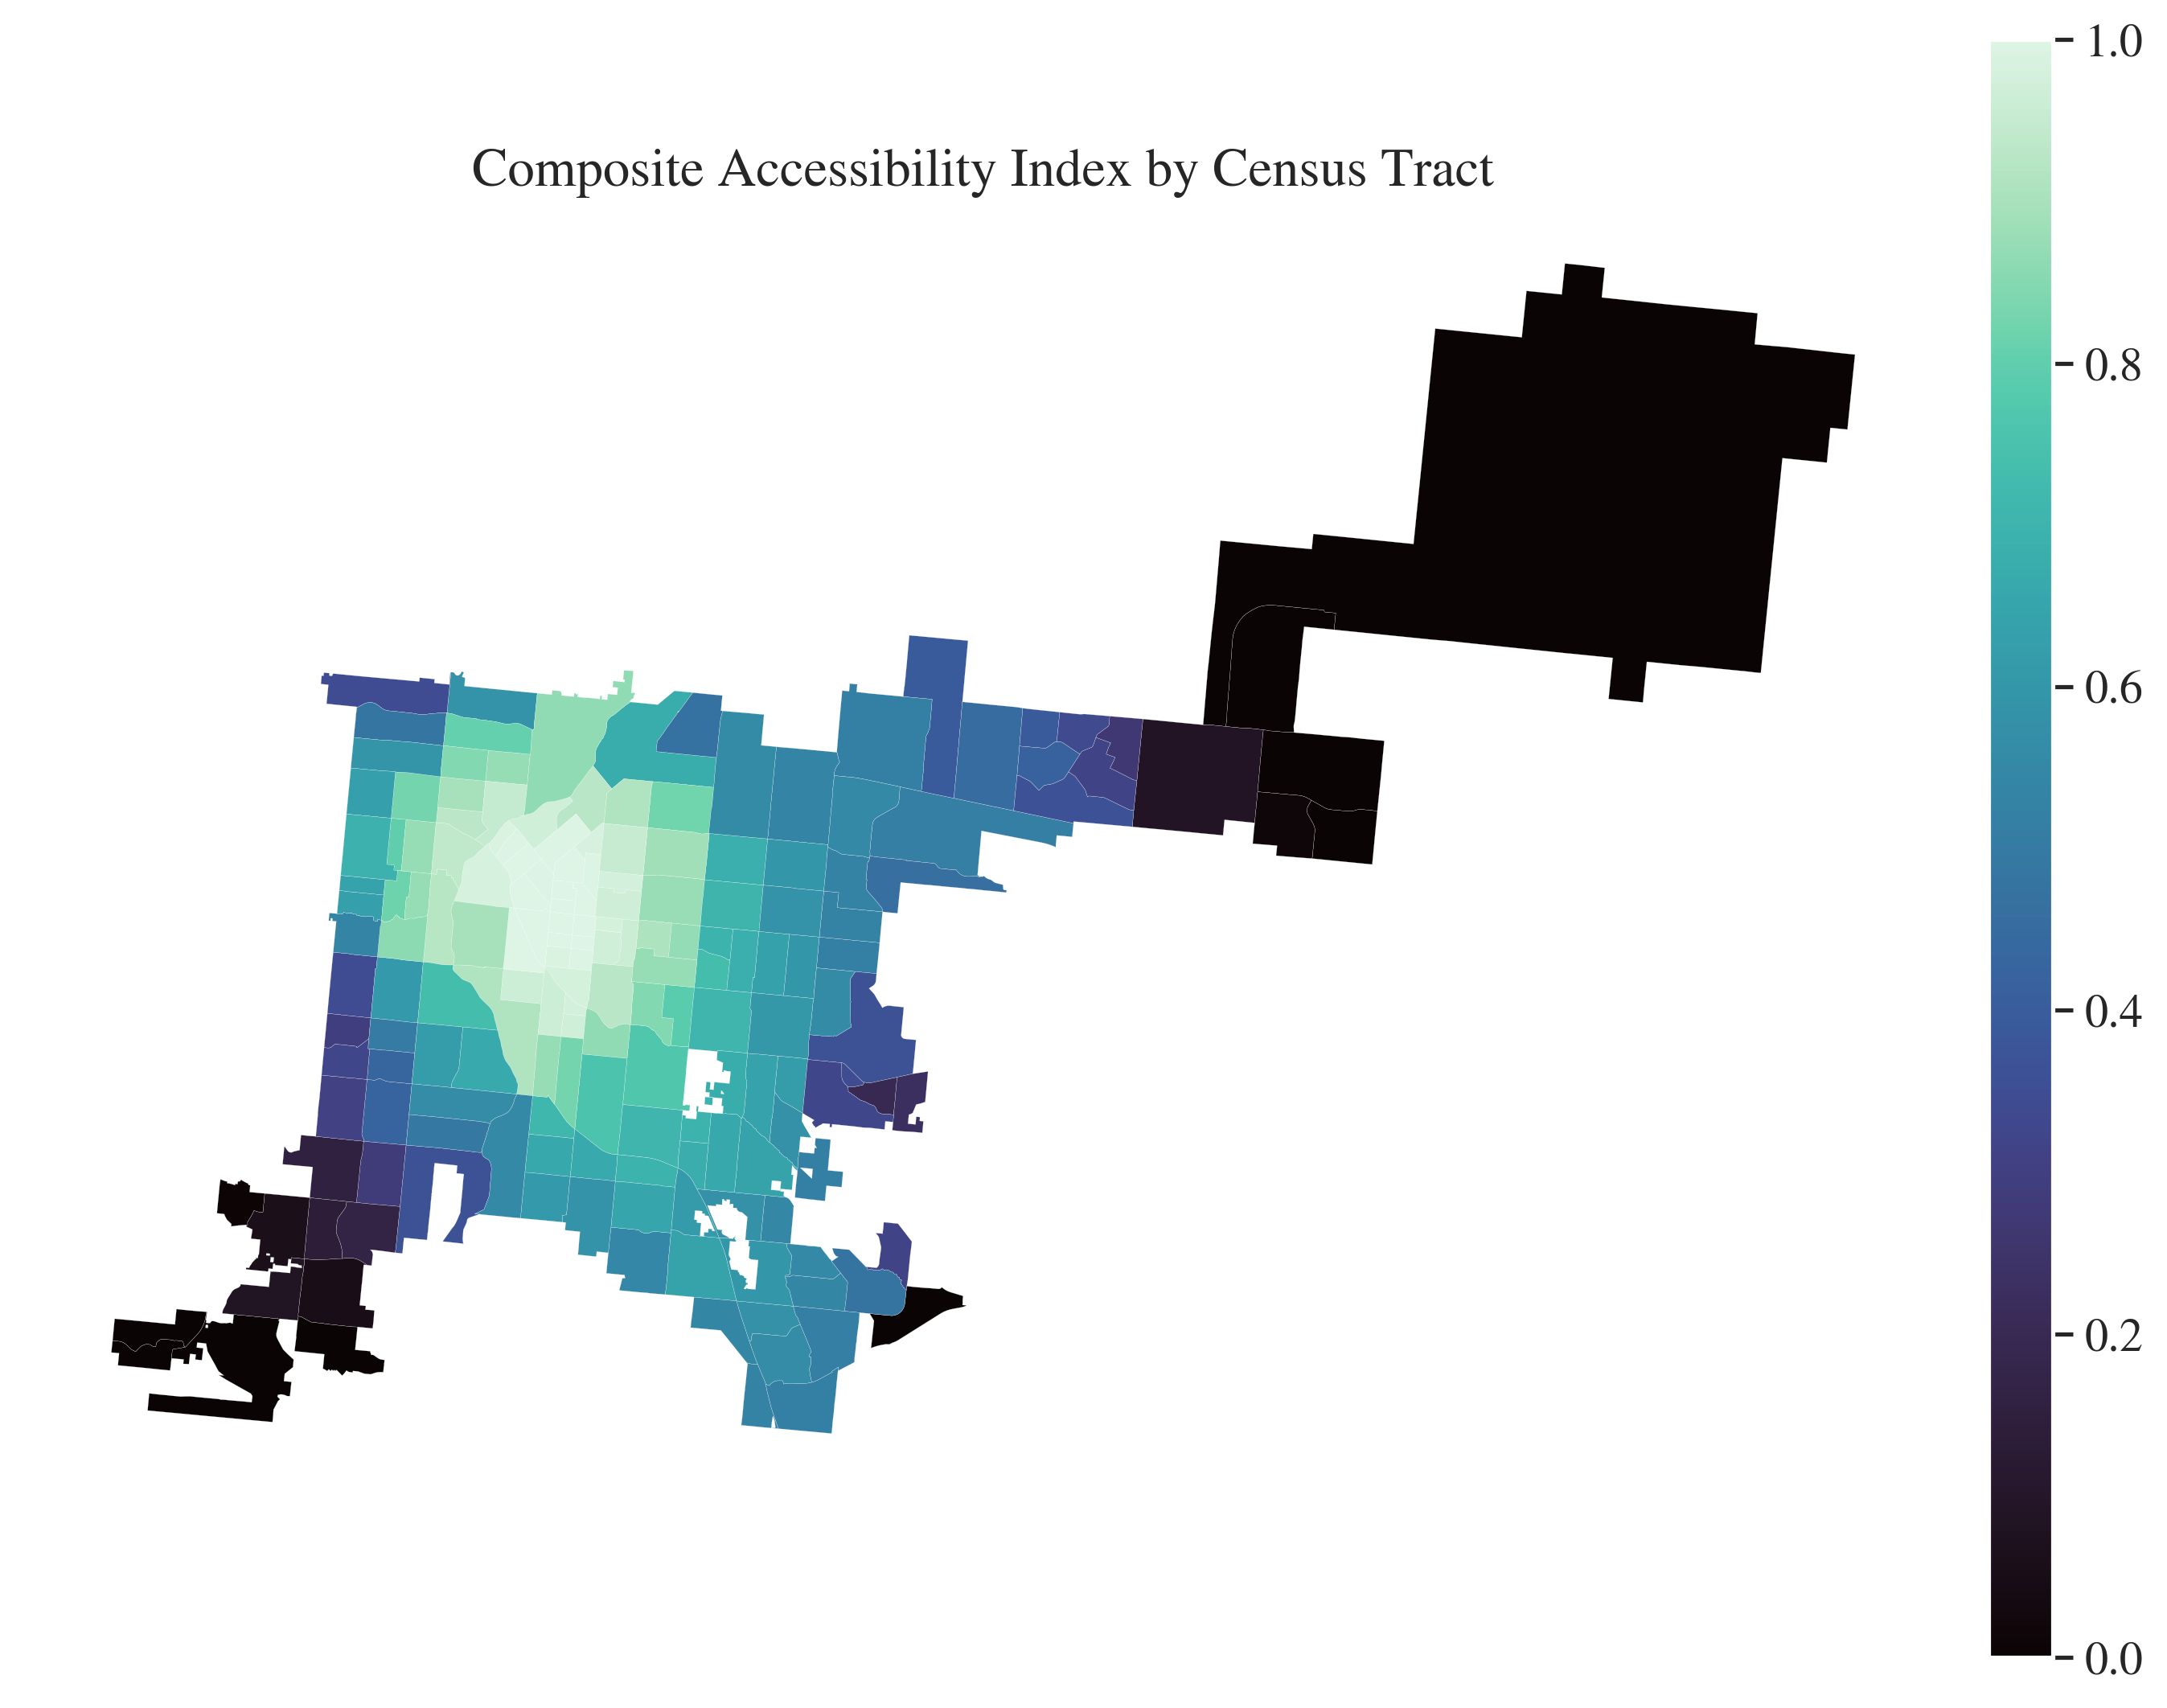

In [8]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.titlesize": 16
})

gdf = gdf.to_crs(epsg=5070).copy()
gdf["access_index_raw"] = gdf["access_index"]

fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

gdf.plot(
    column="access_index_raw",
    cmap="mako",
    legend=True,
    ax=ax,
    linewidth=0.05,          # subtle boundaries
    edgecolor="white",       # matches histogram "clean separation"
    missing_kwds={
        "color": "lightgrey",
        "label": "Missing"
    },
    legend_kwds={
        "shrink": 0.7,
        "aspect": 25,
        "pad": 0.02
    }
)

ax.set_title("Composite Accessibility Index by Census Tract")
ax.axis("off")

plt.tight_layout()
plt.show()

## Training

In [9]:
# Compute centroids for clustering
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

coords = np.column_stack([gdf["x"], gdf["y"]])

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init="auto"
)

gdf["cluster"] = kmeans.fit_predict(coords)

In [10]:
# Select features
drop_cols = [
    "tract_id",
    "from_id",
    "geometry",
    "centroid",
    "x",
    "y",
    "cluster",
    "access_index",
    "access_index_raw"
]

feature_cols = [c for c in gdf.columns if c not in drop_cols]

X = gdf[feature_cols]
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

y = gdf["access_index"]

print("Features:", len(feature_cols))
print("Feature columns:", feature_cols)

Features: 43
Feature columns: ['total_population', 'population_density', 'pct_under_18', 'pct_18_64', 'pct_over_65', 'sex_ratio', 'median_age', 'avg_household_size', 'households', 'median_household_income', 'per_capita_income', 'poverty_rate', 'unemployment_rate', 'labor_force_participation_rate', 'snap_participation_rate', 'public_assistance_rate', 'pct_high_school', 'pct_bachelors_degree', 'pct_graduate_degree', 'pct_no_vehicle_households', 'pct_one_vehicle_households', 'pct_two_plus_vehicle_households', 'median_commute_time', 'pct_public_transit_commute', 'pct_car_commute', 'pct_walk_commute', 'pct_bike_commute', 'pct_work_from_home', 'housing_units', 'occupied_housing_units', 'vacant_housing_units', 'homeownership_rate', 'median_rent', 'median_home_value', 'housing_density', 'median_year_built', 'land_area_km2', 'distance_to_cbd_km', 'pct_white_non_hispanic', 'pct_black', 'pct_hispanic_latino', 'pct_asian', 'pct_other_multiracial']


In [11]:
# Spatial Cross-Validation Loop
results = []
all_predictions = []
feature_importance_list = []

for test_cluster in range(N_CLUSTERS):

    print("\n" + "=" * 60)
    print(f"TEST CLUSTER: {test_cluster}")
    print("=" * 60)

    train_mask = gdf["cluster"] != test_cluster
    test_mask = gdf["cluster"] == test_cluster

    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]

    model = XGBRegressor(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        reg_lambda=10,
        objective="reg:squarederror",
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train, verbose=False)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:,.4f}")
    print(f"RMSE: {rmse:,.4f}")
    print(f"R2:   {r2:.4f}")

    results.append({
        "cluster": test_cluster,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

    # predictions
    fold_preds = pd.DataFrame({
        "tract_id": gdf.loc[test_mask, "tract_id"].values,
        "cluster": test_cluster,
        "actual": y_test.values,
        "predicted": y_pred
    })

    all_predictions.append(fold_preds)

    # feature importance
    feature_importance_list.append(pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_,
        "cluster": test_cluster
    }))

# CONCAT PREDICTIONS
predictions_df = pd.concat(all_predictions, ignore_index=True)


TEST CLUSTER: 0
MAE:  0.1489
RMSE: 0.1732
R2:   -0.2122

TEST CLUSTER: 1
MAE:  0.0657
RMSE: 0.0864
R2:   0.7780

TEST CLUSTER: 2
MAE:  0.1590
RMSE: 0.1787
R2:   0.1596

TEST CLUSTER: 3
MAE:  0.1949
RMSE: 0.2400
R2:   -0.0052

TEST CLUSTER: 4
MAE:  0.0533
RMSE: 0.0698
R2:   0.8310


## Evaluation

In [12]:
# RESULTS SUMMARY
results_df = pd.DataFrame(results)
results_df

# %%
print("\nOVERALL PERFORMANCE")
print(results_df[["mae", "rmse", "r2"]].mean())


OVERALL PERFORMANCE
mae     0.124362
rmse    0.149626
r2      0.310259
dtype: float64


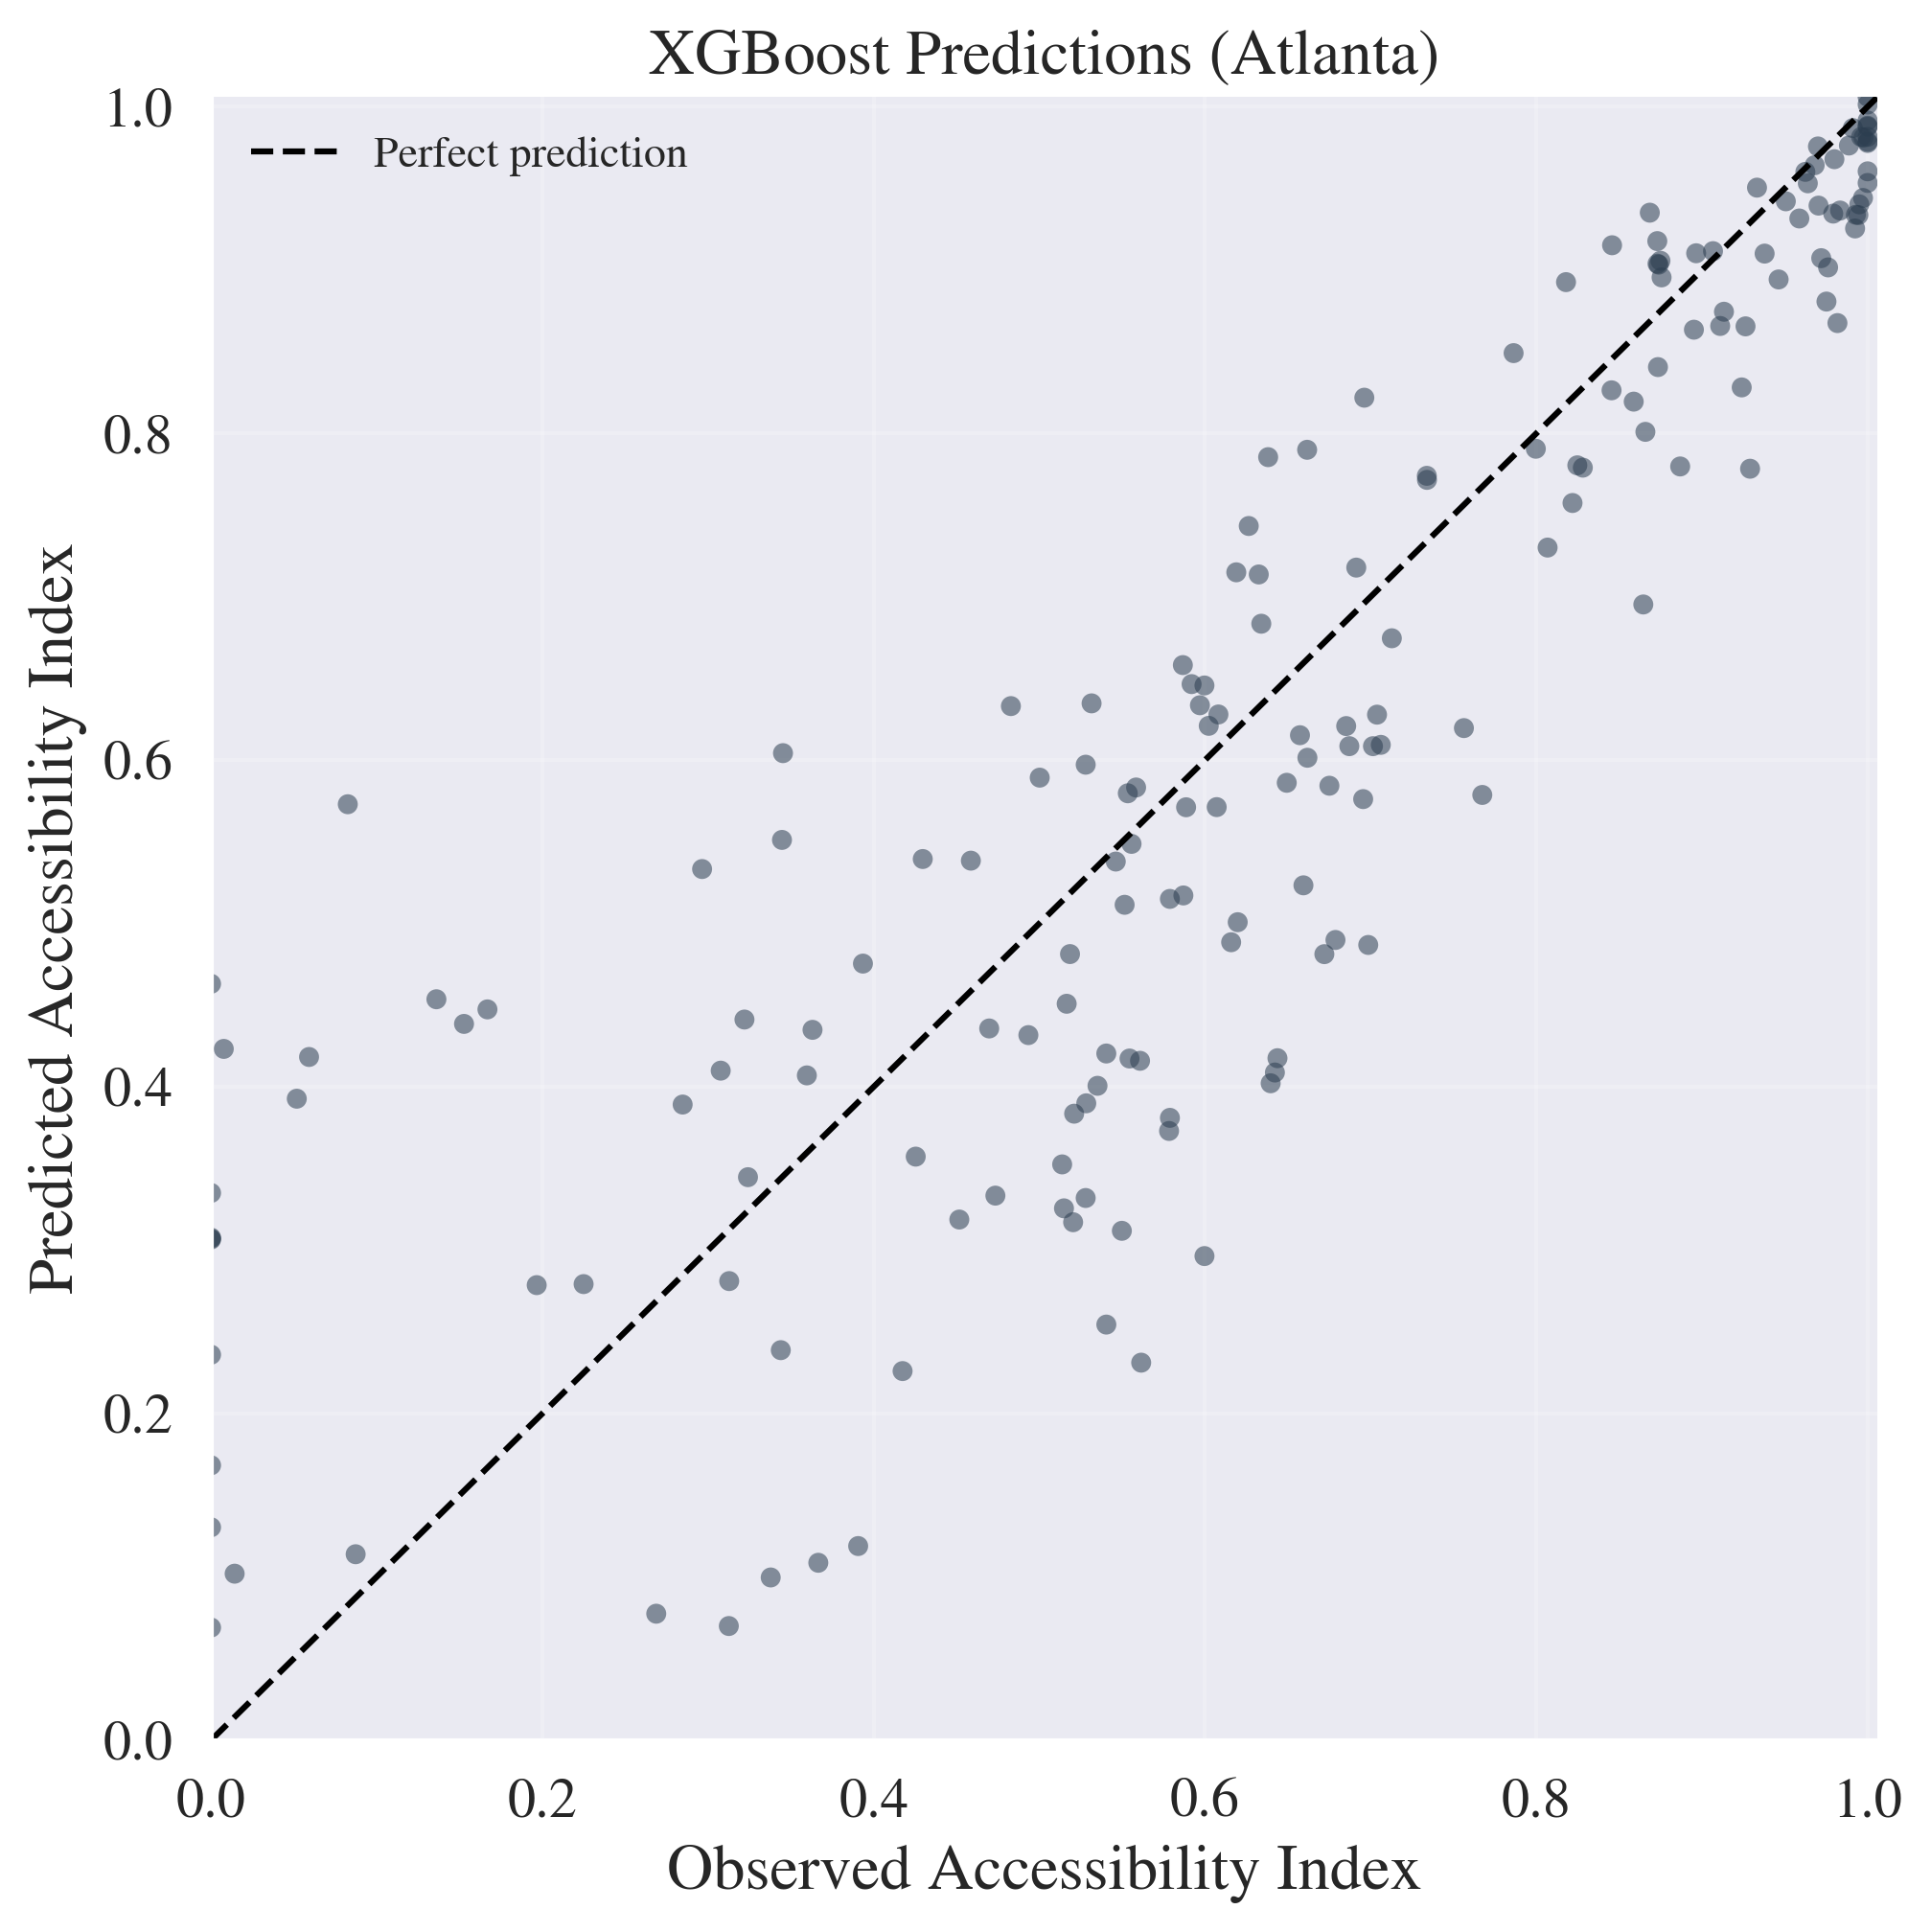

In [13]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2
})

fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# Scatter points
ax.scatter(
    predictions_df["actual"],
    predictions_df["predicted"],
    s=25,
    alpha=0.55,
    color="#2C3E50",
    edgecolors="none"
)

# 1:1 reference line
min_val = min(
    predictions_df["actual"].min(),
    predictions_df["predicted"].min()
)
max_val = max(
    predictions_df["actual"].max(),
    predictions_df["predicted"].max()
)

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    color="black",
    linewidth=1.5,
    label="Perfect prediction"
)

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.set_xlabel("Observed Accessibility Index")
ax.set_ylabel("Predicted Accessibility Index")
ax.set_title("XGBoost Predictions (Atlanta)")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [14]:
# FEATURE IMPORTANCE
importance_df = pd.concat(feature_importance_list, ignore_index=True)

importance_summary = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

importance_summary.head(20)

,feature,importance
0,distance_to_cbd_km,0.278059
1,pct_bachelors_degree,0.095284
2,pct_graduate_degree,0.076506
3,pct_walk_commute,0.062605
4,pct_car_commute,0.049295
5,pct_high_school,0.036379
6,per_capita_income,0.035260
7,pct_white_non_hispanic,0.022824
8,snap_participation_rate,0.022655
9,median_home_value,0.021229


In [15]:
common_style = dict(
    cmap="mako",  # or keep mako if you want, but viridis is cleaner
    legend=True,
    linewidth=0.05,        # KEY FIX: makes borders subtle
    edgecolor="white",     # KEY FIX: softens boundaries
    missing_kwds={"color": "lightgrey"}
)

In [16]:
# Observed vs predicted map
map_gdf = gdf[["tract_id", "geometry"]].merge(
    predictions_df[["tract_id", "actual", "predicted"]],
    on="tract_id",
    how="inner"
)

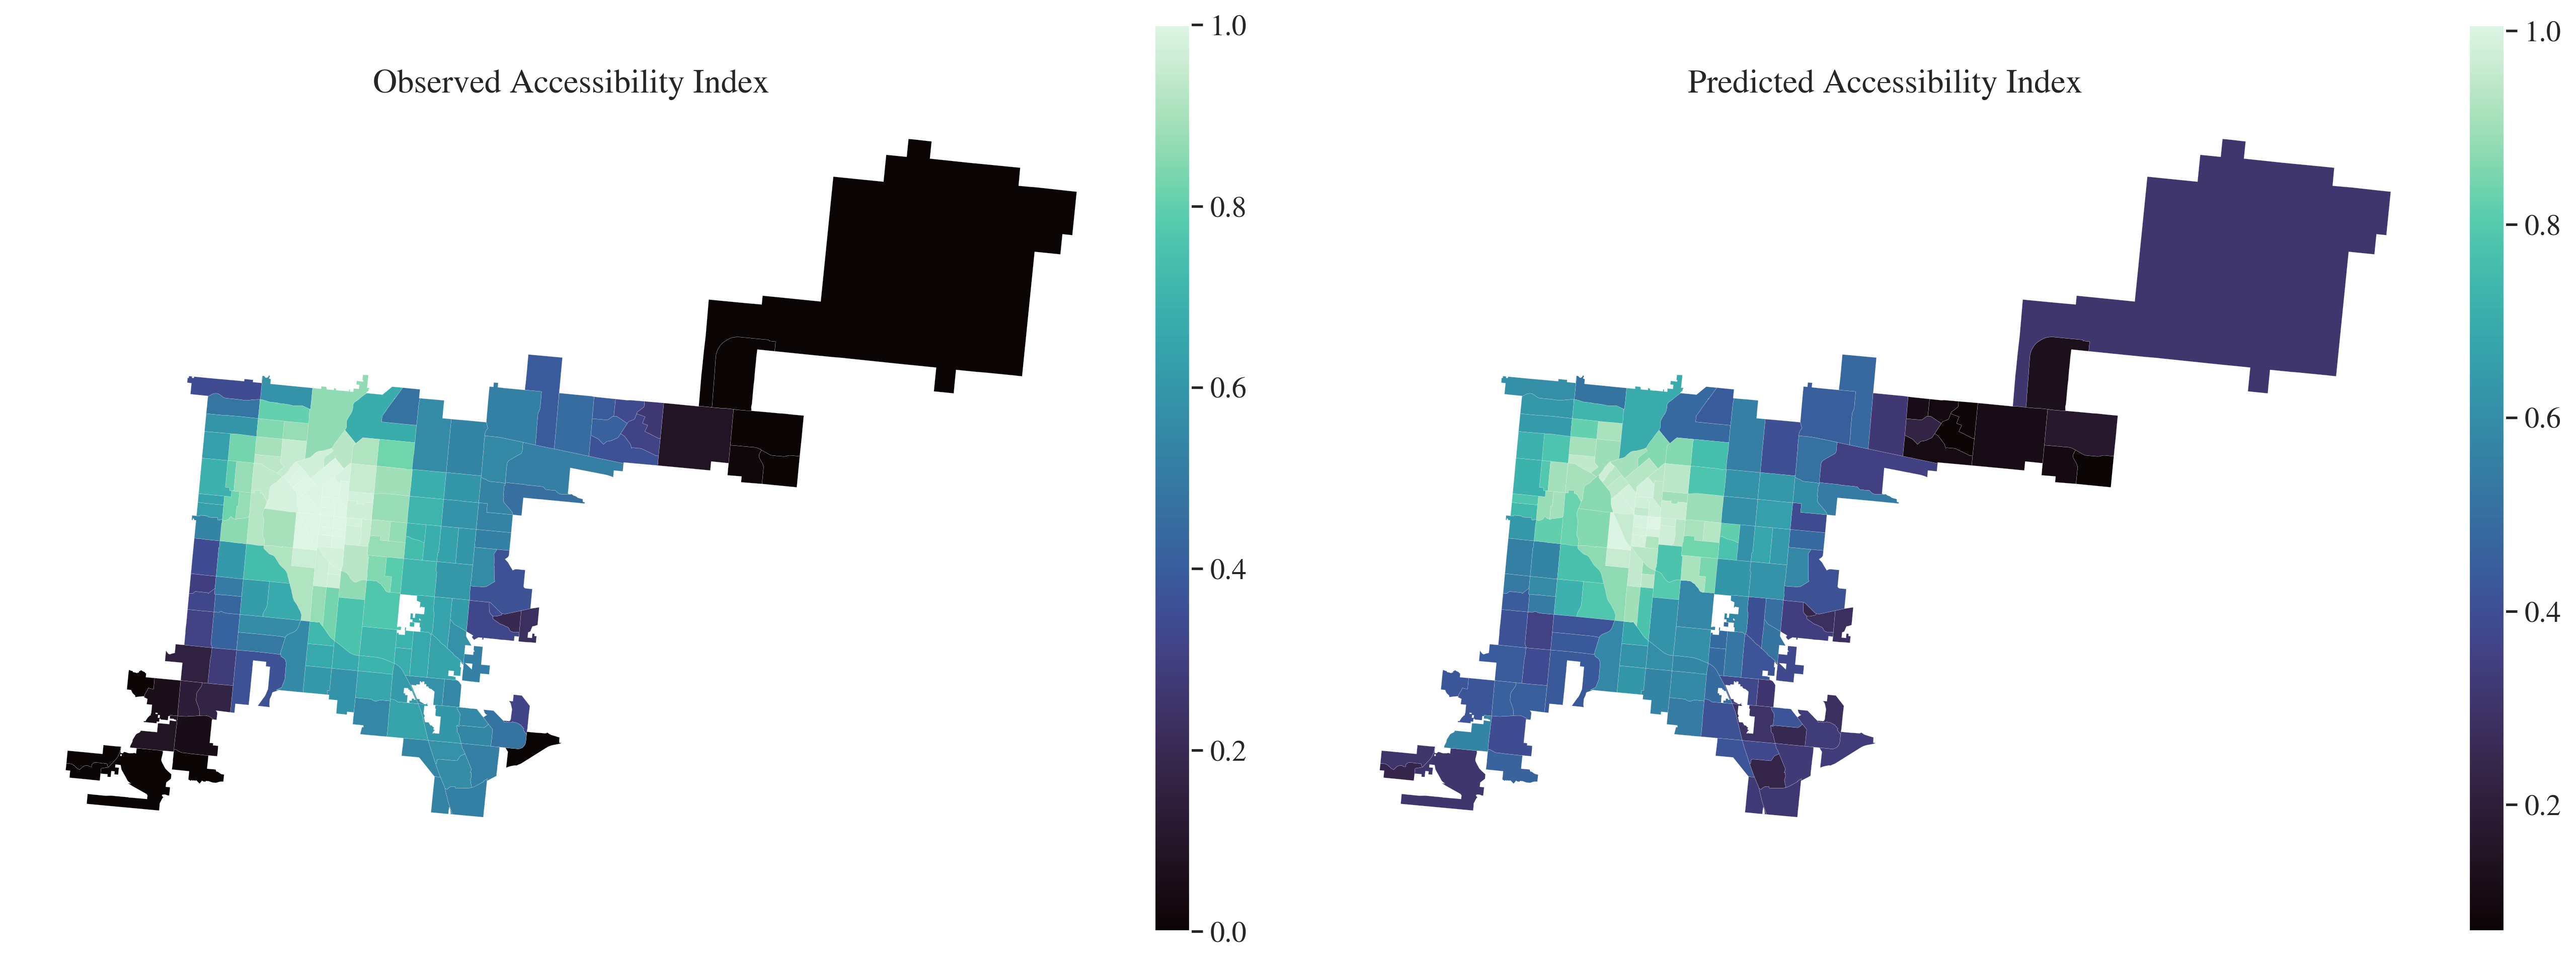

In [17]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.titlesize": 16
})

# Ensure projected CRS like your reference plot
map_gdf = map_gdf.to_crs(epsg=5070).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 9), dpi=300)

# Common styling kwargs
plot_kws = dict(
    cmap="mako",
    legend=True,
    linewidth=0.05,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    legend_kwds={
        "shrink": 0.7,
        "aspect": 25,
        "pad": 0.02
    }
)

# Observed
map_gdf.plot(
    column="actual",
    ax=axes[0],
    **plot_kws
)
axes[0].set_title("Observed Accessibility Index")
axes[0].axis("off")

# Predicted
map_gdf.plot(
    column="predicted",
    ax=axes[1],
    **plot_kws
)
axes[1].set_title("Predicted Accessibility Index")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## SHAP Analysis

In [18]:
# TRAIN FINAL MODEL ON FULL DATASET
final_model = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_lambda=10,
    objective="reg:squarederror",
    random_state=RANDOM_STATE
)

final_model.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [19]:
# COMPUTE SHAP VALUES
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X)

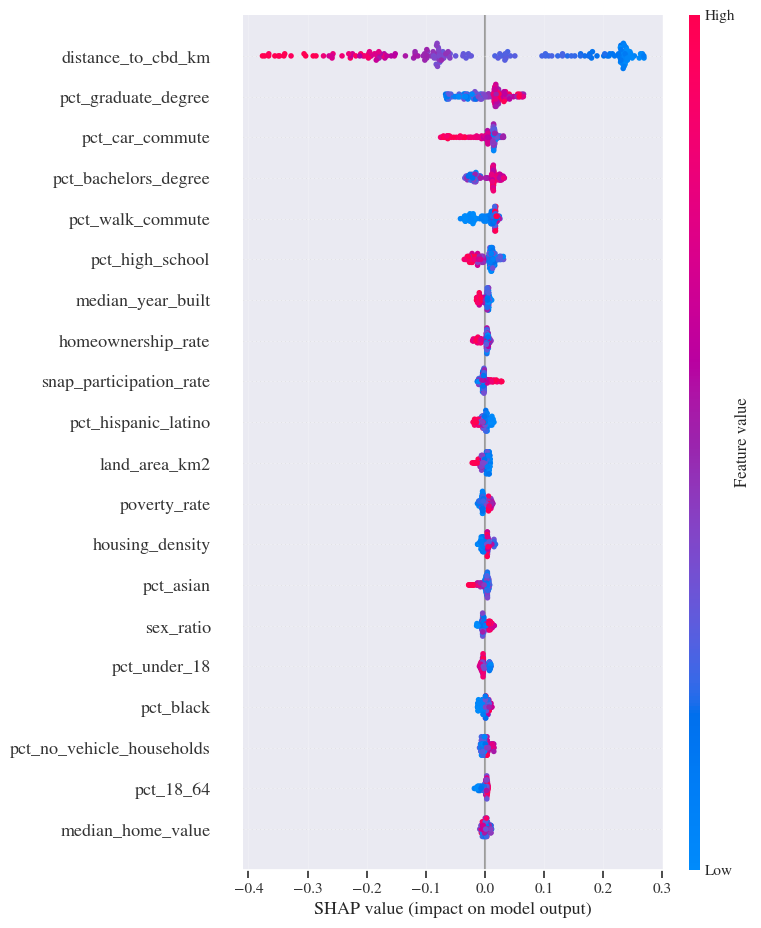

In [20]:
# SHAP SUMMARY PLOT
shap.summary_plot(
    shap_values,
    X,
    feature_names=feature_cols,
    show=False
)

plt.tight_layout()
plt.show()

In [21]:
# %%
# SHAP FEATURE IMPORTANCE TABLE

shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.head(20)

,feature,mean_abs_shap
37,distance_to_cbd_km,0.169830
18,pct_graduate_degree,0.028925
24,pct_car_commute,0.019702
17,pct_bachelors_degree,0.018963
25,pct_walk_commute,0.017068
16,pct_high_school,0.014569
35,median_year_built,0.006194
31,homeownership_rate,0.006080
14,snap_participation_rate,0.005936
40,pct_hispanic_latino,0.005658


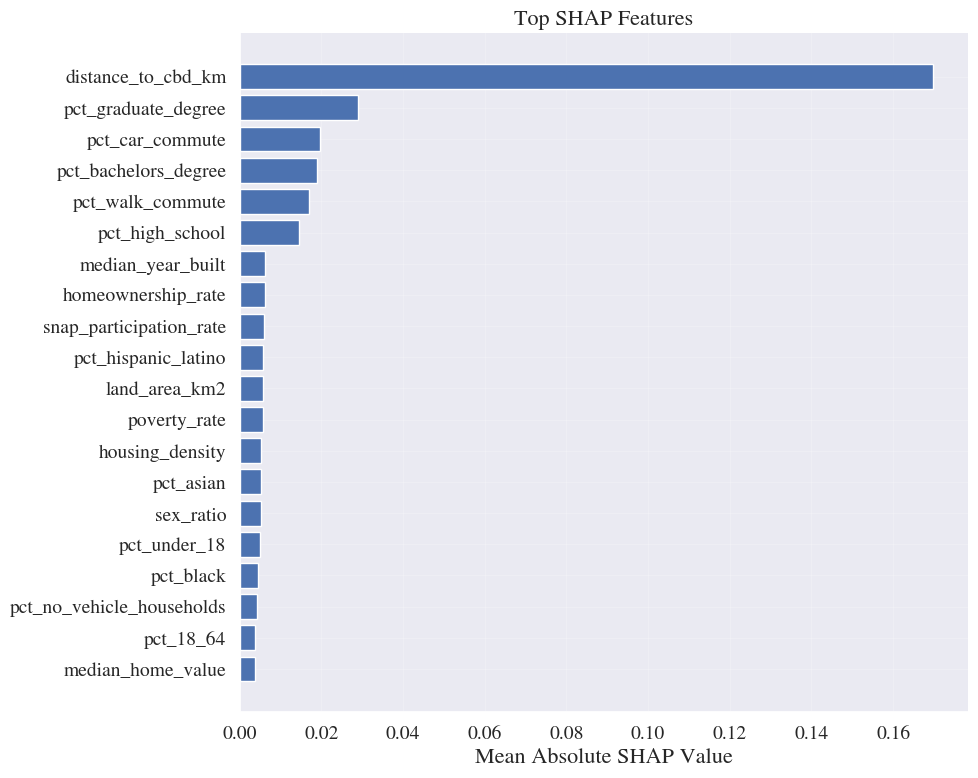

In [22]:
# %%
# SHAP BAR PLOT

top_n = 20

plot_df = shap_importance.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    plot_df["feature"][::-1],
    plot_df["mean_abs_shap"][::-1]
)

ax.set_title("Top SHAP Features")
ax.set_xlabel("Mean Absolute SHAP Value")

plt.tight_layout()
plt.show()